# Predicting Delayed Flights

### Austin Melendez
#### 2/24/2026

In [47]:
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

### Review <i>Normalizing and Rescaling Data Based on the Training Data</i> in the example code of DMBA Chapter 2. Read DMBA Chapter 10.6 Example of Complete Analysis: Predicting Delayed Flights, up to the section "Data Preprocessing". Review the code below and then complete this assignment.

## 10.6 EXAMPLE OF COMPLETE ANALYSIS PREDICTING DELAYED FLIGHTS
### Goal 1: 
<b><i>Classification</i></b> of new flights - classify new flights based on their predictors.
### Goal 2: 
<b><i>Ranking</i></b> - find a certain percentage of flights that are most/least likely to get delayed.
### Goal 3: 
<b><i>Profiling</i></b> flights - find out which factors are associated with a delay and quantify these effects.

## Figure 10.4

In [48]:
delays_df = pd.read_csv("~/DS110/data/FlightDelays.csv")
delays_df

,CRS_DEP_TIME,CARRIER,DEP_TIME,DEST,DISTANCE,FL_DATE,FL_NUM,ORIGIN,Weather,DAY_WEEK,DAY_OF_MONTH,TAIL_NUM,Flight Status
0,1455,OH,1455,JFK,184,01/01/2004,5935,BWI,0,4,1,N940CA,ontime
1,1640,DH,1640,JFK,213,01/01/2004,6155,DCA,0,4,1,N405FJ,ontime
2,1245,DH,1245,LGA,229,01/01/2004,7208,IAD,0,4,1,N695BR,ontime
3,1715,DH,1709,LGA,229,01/01/2004,7215,IAD,0,4,1,N662BR,ontime
4,1039,DH,1035,LGA,229,01/01/2004,7792,IAD,0,4,1,N698BR,ontime
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2196,645,RU,644,EWR,199,1/31/2004,2761,DCA,0,6,31,N15555,ontime
2197,1700,RU,1653,EWR,213,1/31/2004,2497,IAD,0,6,31,N16976,ontime
2198,1600,RU,1558,EWR,199,1/31/2004,2361,DCA,0,6,31,N14902,ontime
2199,1359,RU,1403,EWR,199,1/31/2004,2216,DCA,0,6,31,N16961,ontime


In [49]:
delays_df.columns

Index(['CRS_DEP_TIME', 'CARRIER', 'DEP_TIME', 'DEST', 'DISTANCE', 'FL_DATE',
       'FL_NUM', 'ORIGIN', 'Weather', 'DAY_WEEK', 'DAY_OF_MONTH', 'TAIL_NUM',
       'Flight Status'],
      dtype='object')

In [50]:
delays_df['Flight Status'].value_counts()

Flight Status
ontime     1773
delayed     428
Name: count, dtype: int64

In [51]:
428/(1773+428)

0.19445706497046797

In [52]:
delays_df['CARRIER'].value_counts()

CARRIER
DH    551
RU    408
US    404
DL    388
MQ    295
CO     94
UA     31
OH     30
Name: count, dtype: int64

In [53]:
delays_df['ORIGIN'].value_counts()

ORIGIN
DCA    1370
IAD     686
BWI     145
Name: count, dtype: int64

In [54]:
delays_df['DEST'].value_counts()

DEST
LGA    1150
EWR     665
JFK     386
Name: count, dtype: int64

In [55]:
delays_df['DAY_WEEK'].value_counts()

DAY_WEEK
5    391
4    372
3    320
1    308
2    307
7    253
6    250
Name: count, dtype: int64

In [56]:
delays_df['Weather'].value_counts()

Weather
0    2169
1      32
Name: count, dtype: int64

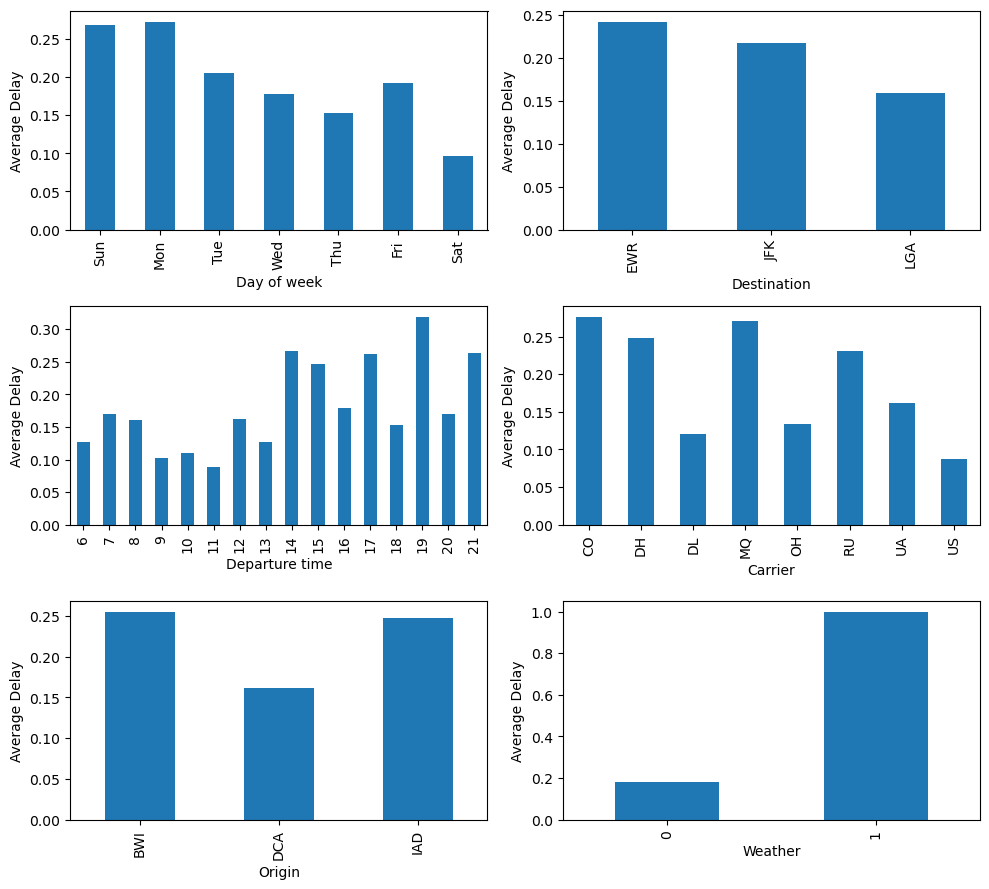

In [57]:
delays_df = pd.read_csv("~/DS110/data/FlightDelays.csv")
# Create an indicator variable
delays_df['isDelayed'] = [1 if status == 'delayed' else 0 
                          for status in delays_df['Flight Status']]

def createGraph(group, xlabel, axis):
    groupAverage = delays_df.groupby([group])['isDelayed'].mean()
    if group == 'DAY_WEEK': # rotate so that display starts on Sunday
        groupAverage = groupAverage.reindex(index=np.roll(groupAverage.index,1))
        groupAverage.index = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']
    ax = groupAverage.plot.bar(color='C0', ax=axis)
    ax.set_ylabel('Average Delay')
    ax.set_xlabel(xlabel)
    return ax

def graphDepartureTime(xlabel, axis):
    temp_df = pd.DataFrame({'CRS_DEP_TIME': delays_df['CRS_DEP_TIME'] // 100, 
                            'isDelayed': delays_df['isDelayed']})
    groupAverage = temp_df.groupby(['CRS_DEP_TIME'])['isDelayed'].mean()
    ax = groupAverage.plot.bar(color='C0', ax=axis)
    ax.set_xlabel(xlabel); ax.set_ylabel('Average Delay')
    
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 9))

createGraph('DAY_WEEK', 'Day of week', axis=axes[0][0])
createGraph('DEST', 'Destination', axis=axes[0][1])
graphDepartureTime('Departure time', axis=axes[1][0])
createGraph('CARRIER', 'Carrier', axis=axes[1][1])
createGraph('ORIGIN', 'Origin', axis=axes[2][0])
createGraph('Weather', 'Weather', axis=axes[2][1])
plt.tight_layout()

plt.show()

## Figure 10.5

/tmp/ipykernel_102/2392578224.py:16: FutureWarning: The provided callable <function sum at 0x7f118d3407c0> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  data = pd.pivot_table(agg[agg.ORIGIN == origin], values='isDelayed', aggfunc=np.sum,
/tmp/ipykernel_102/2392578224.py:16: FutureWarning: The provided callable <function sum at 0x7f118d3407c0> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  data = pd.pivot_table(agg[agg.ORIGIN == origin], values='isDelayed', aggfunc=np.sum,
/tmp/ipykernel_102/2392578224.py:16: FutureWarning: The provided callable <function sum at 0x7f118d3407c0> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "

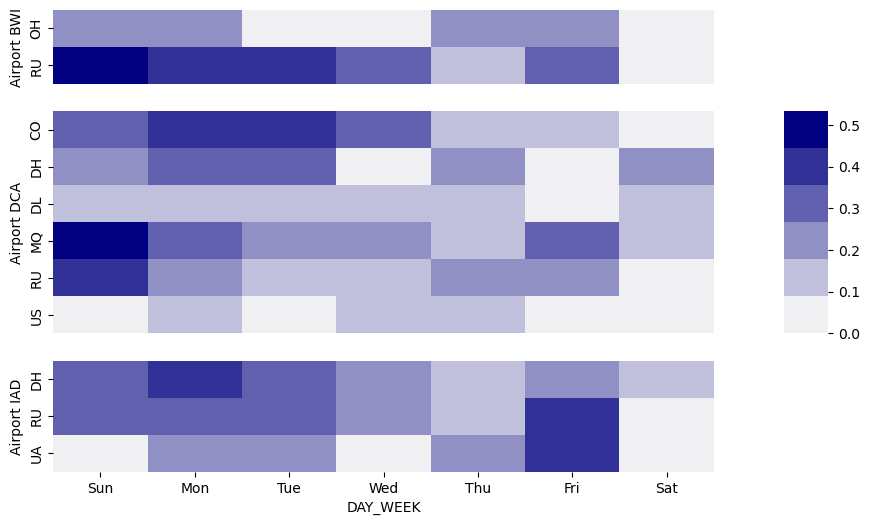

In [58]:
agg = delays_df.groupby(['ORIGIN', 'DAY_WEEK', 'CARRIER']).isDelayed.mean()
agg = agg.reset_index()

# Define the layout of the graph
height_ratios = []
for i, origin in enumerate(sorted(delays_df.ORIGIN.unique())):
    height_ratios.append(len(agg[agg.ORIGIN == origin].CARRIER.unique()))
gridspec_kw = {'height_ratios': height_ratios, 'width_ratios': [15, 1]}
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 6), 
                         gridspec_kw = gridspec_kw)
axes[0, 1].axis('off')
axes[2, 1].axis('off')

maxIsDelay = agg.isDelayed.max()
for i, origin in enumerate(sorted(delays_df.ORIGIN.unique())):
    data = pd.pivot_table(agg[agg.ORIGIN == origin], values='isDelayed', aggfunc=np.sum, 
                          index=['CARRIER'], columns=['DAY_WEEK'])
    data = data[[7, 1, 2, 3, 4, 5, 6]]  # Shift last columns to first
    ax = sns.heatmap(data, ax=axes[i][0], vmin=0, vmax=maxIsDelay, 
                     cbar_ax=axes[1][1], cmap=sns.light_palette("navy"))
    ax.set_xticklabels(['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat'])
    if i != 2: 
        ax.get_xaxis().set_visible(False)
    ax.set_ylabel('Airport ' + origin)
    

plt.show()

In [59]:
delays_df = pd.read_csv("~/DS110/data/FlightDelays.csv")
# Create an indicator variable
delays_df['isDelayed'] = [1 if status == 'delayed' else 0 
                          for status in delays_df['Flight Status']]

# convert to categorical
delays_df.DAY_WEEK = delays_df.DAY_WEEK.astype('category')

# create hourly bins departure time 
delays_df.CRS_DEP_TIME = [round(t / 100) for t in delays_df.CRS_DEP_TIME]
delays_df.CRS_DEP_TIME = delays_df.CRS_DEP_TIME.astype('category')

predictors = ['DAY_WEEK', 'CRS_DEP_TIME', 'ORIGIN', 'DEST', 'CARRIER', 'Weather']
outcome = 'isDelayed'

X = pd.get_dummies(delays_df[predictors], drop_first=True, dtype=int)
y = delays_df[outcome]
classes = ['ontime', 'delayed']

# split into training and validation
train_X, valid_X, train_y, valid_y = train_test_split(X, y, test_size=0.4, 
                                                      random_state=1)

## Assignment:<p><p>Write code below to standardize (normalize) the train_X and valid_X based on train_X (mean and standard deviation) and print out the descriptive statistics of the standardized train_X and valid_X. Do this in two ways, using pandas and then sklearn's <i>fit()</i>, <i>transform()</i>, <i>fit_transform()</i>.

In [60]:
import sys
import sklearn
print(sys.version)
print('The scikit-learn version is {}.'.format(sklearn.__version__))

3.11.14 | packaged by conda-forge | (main, Oct 22 2025, 22:46:25) [GCC 14.3.0]
The scikit-learn version is 1.7.0.


In [65]:
# Pandas
import pandas as pd

# Calculate mean and std from train
train_mean = train_X.mean()
train_std = train_X.std()

# Standardize training data
train_X_std_pd = (train_X - train_mean) / train_std

# Standardize validation data
valid_X_std_pd = (valid_X - train_mean) / train_std

print("Standardized train set summary:")
print(train_X_std_pd.describe())

print("\n Standardized validation set summary:")
print(valid_X_std_pd.describe())

Standardized train set summary:
            Weather    DAY_WEEK_2    DAY_WEEK_3    DAY_WEEK_4    DAY_WEEK_5  \
count  1.320000e+03  1.320000e+03  1.320000e+03  1.320000e+03  1.320000e+03   
mean   3.498885e-17  6.055762e-18 -4.777323e-17 -5.382900e-17 -6.997769e-17   
std    1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00   
min   -9.574634e-02 -4.086345e-01 -4.010336e-01 -4.506969e-01 -4.567637e-01   
25%   -9.574634e-02 -4.086345e-01 -4.010336e-01 -4.506969e-01 -4.567637e-01   
50%   -9.574634e-02 -4.086345e-01 -4.010336e-01 -4.506969e-01 -4.567637e-01   
75%   -9.574634e-02 -4.086345e-01 -4.010336e-01 -4.506969e-01 -4.567637e-01   
max    1.043635e+01  2.445321e+00  2.491668e+00  2.217105e+00  2.187657e+00   

         DAY_WEEK_6    DAY_WEEK_7  CRS_DEP_TIME_7  CRS_DEP_TIME_8  \
count  1.320000e+03  1.320000e+03    1.320000e+03    1.320000e+03   
mean   1.749442e-17 -2.153160e-17    1.345725e-17    3.498885e-17   
std    1.000000e+00  1.000000e+00    1.000000e+00

In [67]:
# scikit learn
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Initialize scalar
sc = StandardScaler()

# Fit and transform on train
train_X_std_sk = sc.fit_transform(train_X)

# Transform valid using train
valid_X_std_sk = sc.transform(valid_X)

# Convert to pandas df
train_X_std_sk = pd.DataFrame(train_X_std_sk, columns=train_X.columns)
valid_X_std_sk = pd.DataFrame(valid_X_std_sk, columns=valid_X.columns)

print("Standardized train set summary:")
print(train_X_std_sk.describe())

print("\n Standardized validatrion set summary:")
print(valid_X_std_sk.describe())

Standardized train set summary:
            Weather    DAY_WEEK_2    DAY_WEEK_3    DAY_WEEK_4    DAY_WEEK_5  \
count  1.320000e+03  1.320000e+03  1.320000e+03  1.320000e+03  1.320000e+03   
mean  -5.382900e-17 -1.884015e-17 -3.364312e-17 -2.085874e-17  4.171747e-17   
std    1.000379e+00  1.000379e+00  1.000379e+00  1.000379e+00  1.000379e+00   
min   -9.578263e-02 -4.087894e-01 -4.011856e-01 -4.508677e-01 -4.569368e-01   
25%   -9.578263e-02 -4.087894e-01 -4.011856e-01 -4.508677e-01 -4.569368e-01   
50%   -9.578263e-02 -4.087894e-01 -4.011856e-01 -4.508677e-01 -4.569368e-01   
75%   -9.578263e-02 -4.087894e-01 -4.011856e-01 -4.508677e-01 -4.569368e-01   
max    1.044031e+01  2.446248e+00  2.492612e+00  2.217946e+00  2.188487e+00   

         DAY_WEEK_6    DAY_WEEK_7  CRS_DEP_TIME_7  CRS_DEP_TIME_8  \
count  1.320000e+03  1.320000e+03    1.320000e+03    1.320000e+03   
mean   4.171747e-17 -7.266914e-17   -7.536059e-17    6.190334e-17   
std    1.000379e+00  1.000379e+00    1.000379e+00